# Análisis exploratorio

In [83]:
import os
import pathlib
import math

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

In [84]:
data_dir = '../Datasets'
files = [f for f in os.listdir(data_dir) if f.endswith('.csv') and not f.startswith('triplets')]
print(files)

# Material de trabajo:
dfs_dict = {file_name: pd.read_csv(os.path.join(data_dir, file_name)) for file_name in files}
big_df = pd.read_csv(os.path.join(data_dir, "triplets.csv"))

['republica_dominicana.csv', 'peru.csv', 'chile.csv', 'mexico.csv', 'costa_rica.csv', 'paraguay.csv', 'nicaragua.csv', 'usa.csv', 'panama.csv', 'ecuador.csv', 'argentina.csv', 'venezuela.csv', 'colombia.csv', 'guatemala.csv', 'el_salvador.csv', 'honduras.csv', 'cuba.csv']


### 1) Tripletas por archivo

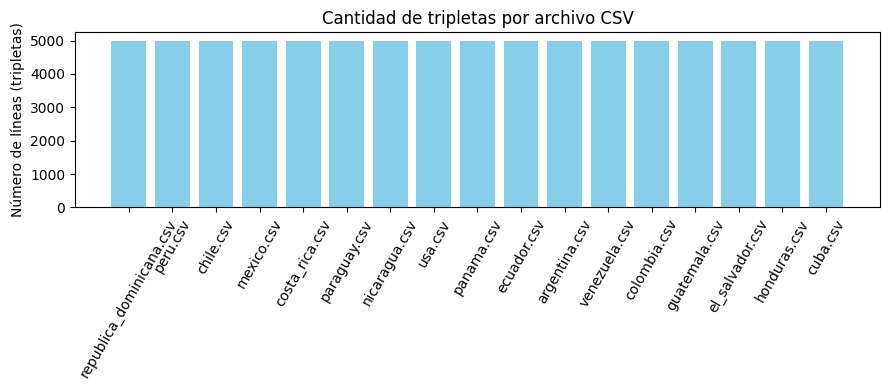

In [85]:
line_counts = {}
for file_name, df in dfs_dict.items():
    line_counts[file_name] = len(df)

plt.figure(figsize=(9, 4))
plt.bar(line_counts.keys(), line_counts.values(), color="skyblue")
plt.ylabel("Número de líneas (tripletas)")
plt.title("Cantidad de tripletas por archivo CSV")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

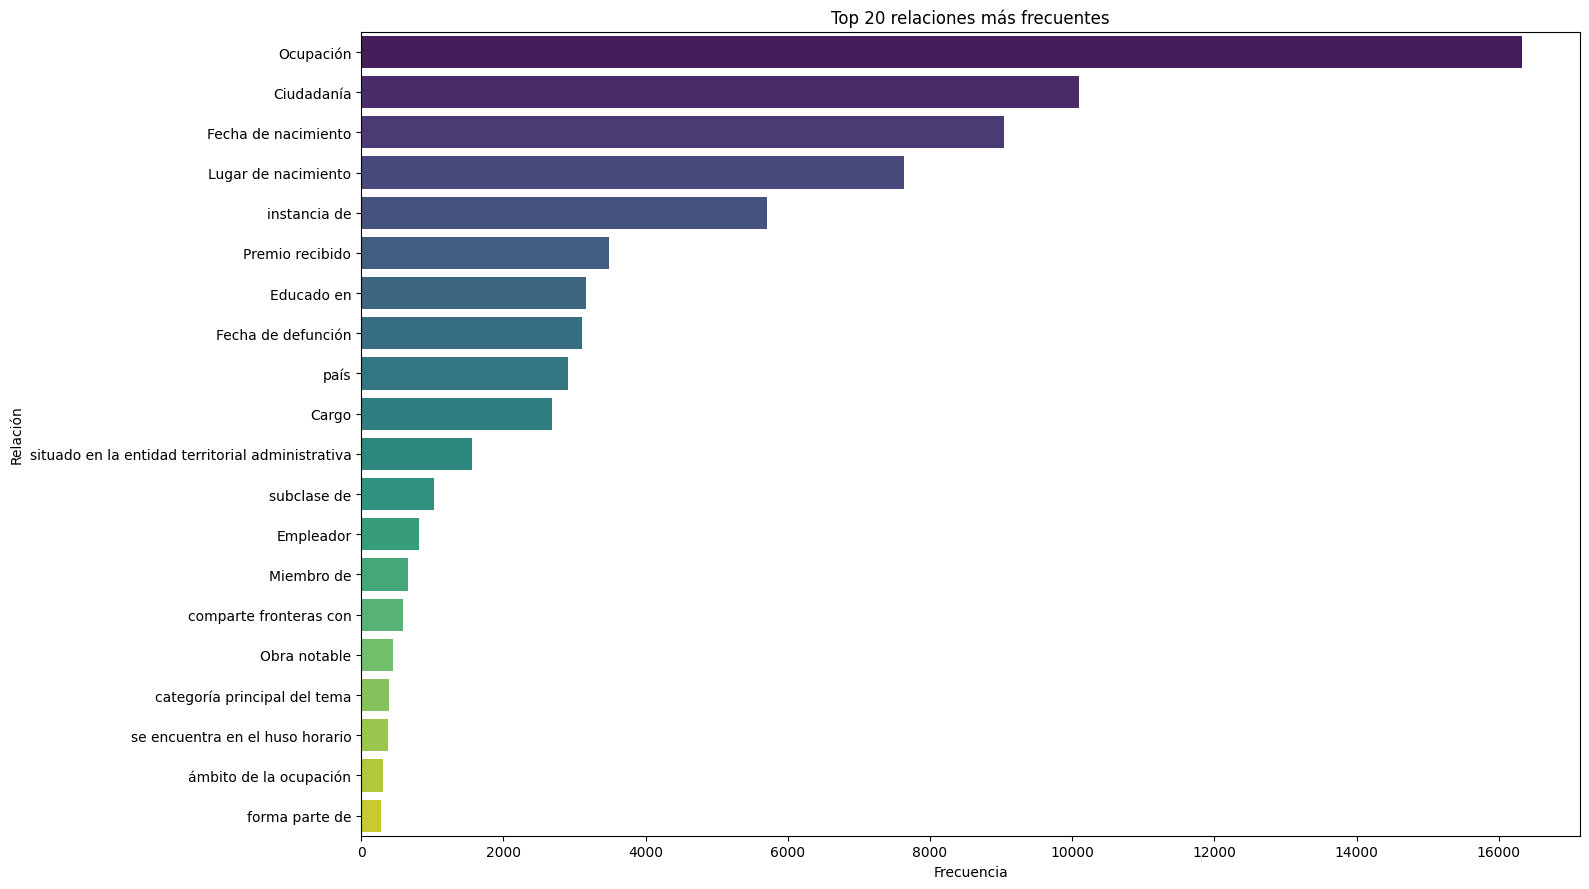

In [86]:
relation_counts = big_df['relacion'].value_counts().reset_index()

top_n = 20
plt.figure(figsize=(16, 9))
sns.barplot(
    data=relation_counts.head(top_n),
    y='relacion',
    x='count',
    hue='relacion',
    palette='viridis',
    legend=False
)
plt.xlabel('Frecuencia')
plt.ylabel('Relación')
plt.title(f'Top {top_n} relaciones más frecuentes')
plt.tight_layout()
plt.show()


### 2) Relaciones promedio por entidad

In [87]:
def relations_per_entity_hist_all():
    total_files = len(dfs_dict)

    max_x = 0
    max_y = 0
    data_dict = {}

    # Precalcula grados por archivo y máximos globales
    for name, df in dfs_dict.items():
        entity_degrees = df['entidad'].value_counts()
        data_dict[name] = entity_degrees
        max_x = max(max_x, entity_degrees.max())
        max_y = max(max_y, entity_degrees.value_counts().max())

    cols = 3 if total_files >= 3 else total_files
    rows = math.ceil(total_files / cols) if total_files > 0 else 1
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
    axes = axes.flatten() if total_files > 1 else [axes]

    for i, name in enumerate(dfs_dict.keys()):
        sns.histplot(data_dict[name], bins=30, kde=False, ax=axes[i])
        axes[i].set_xmargin(0)
        axes[i].set_xlim(0, max_x * 1.05)
        axes[i].set_yscale('log')
        axes[i].set_ylim(1, max_y * 1.2)
        axes[i].set_xlabel('Relaciones por entidad')
        axes[i].set_ylabel('Frecuencia (log)')
        axes[i].set_title(name.replace('.csv', ''))

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

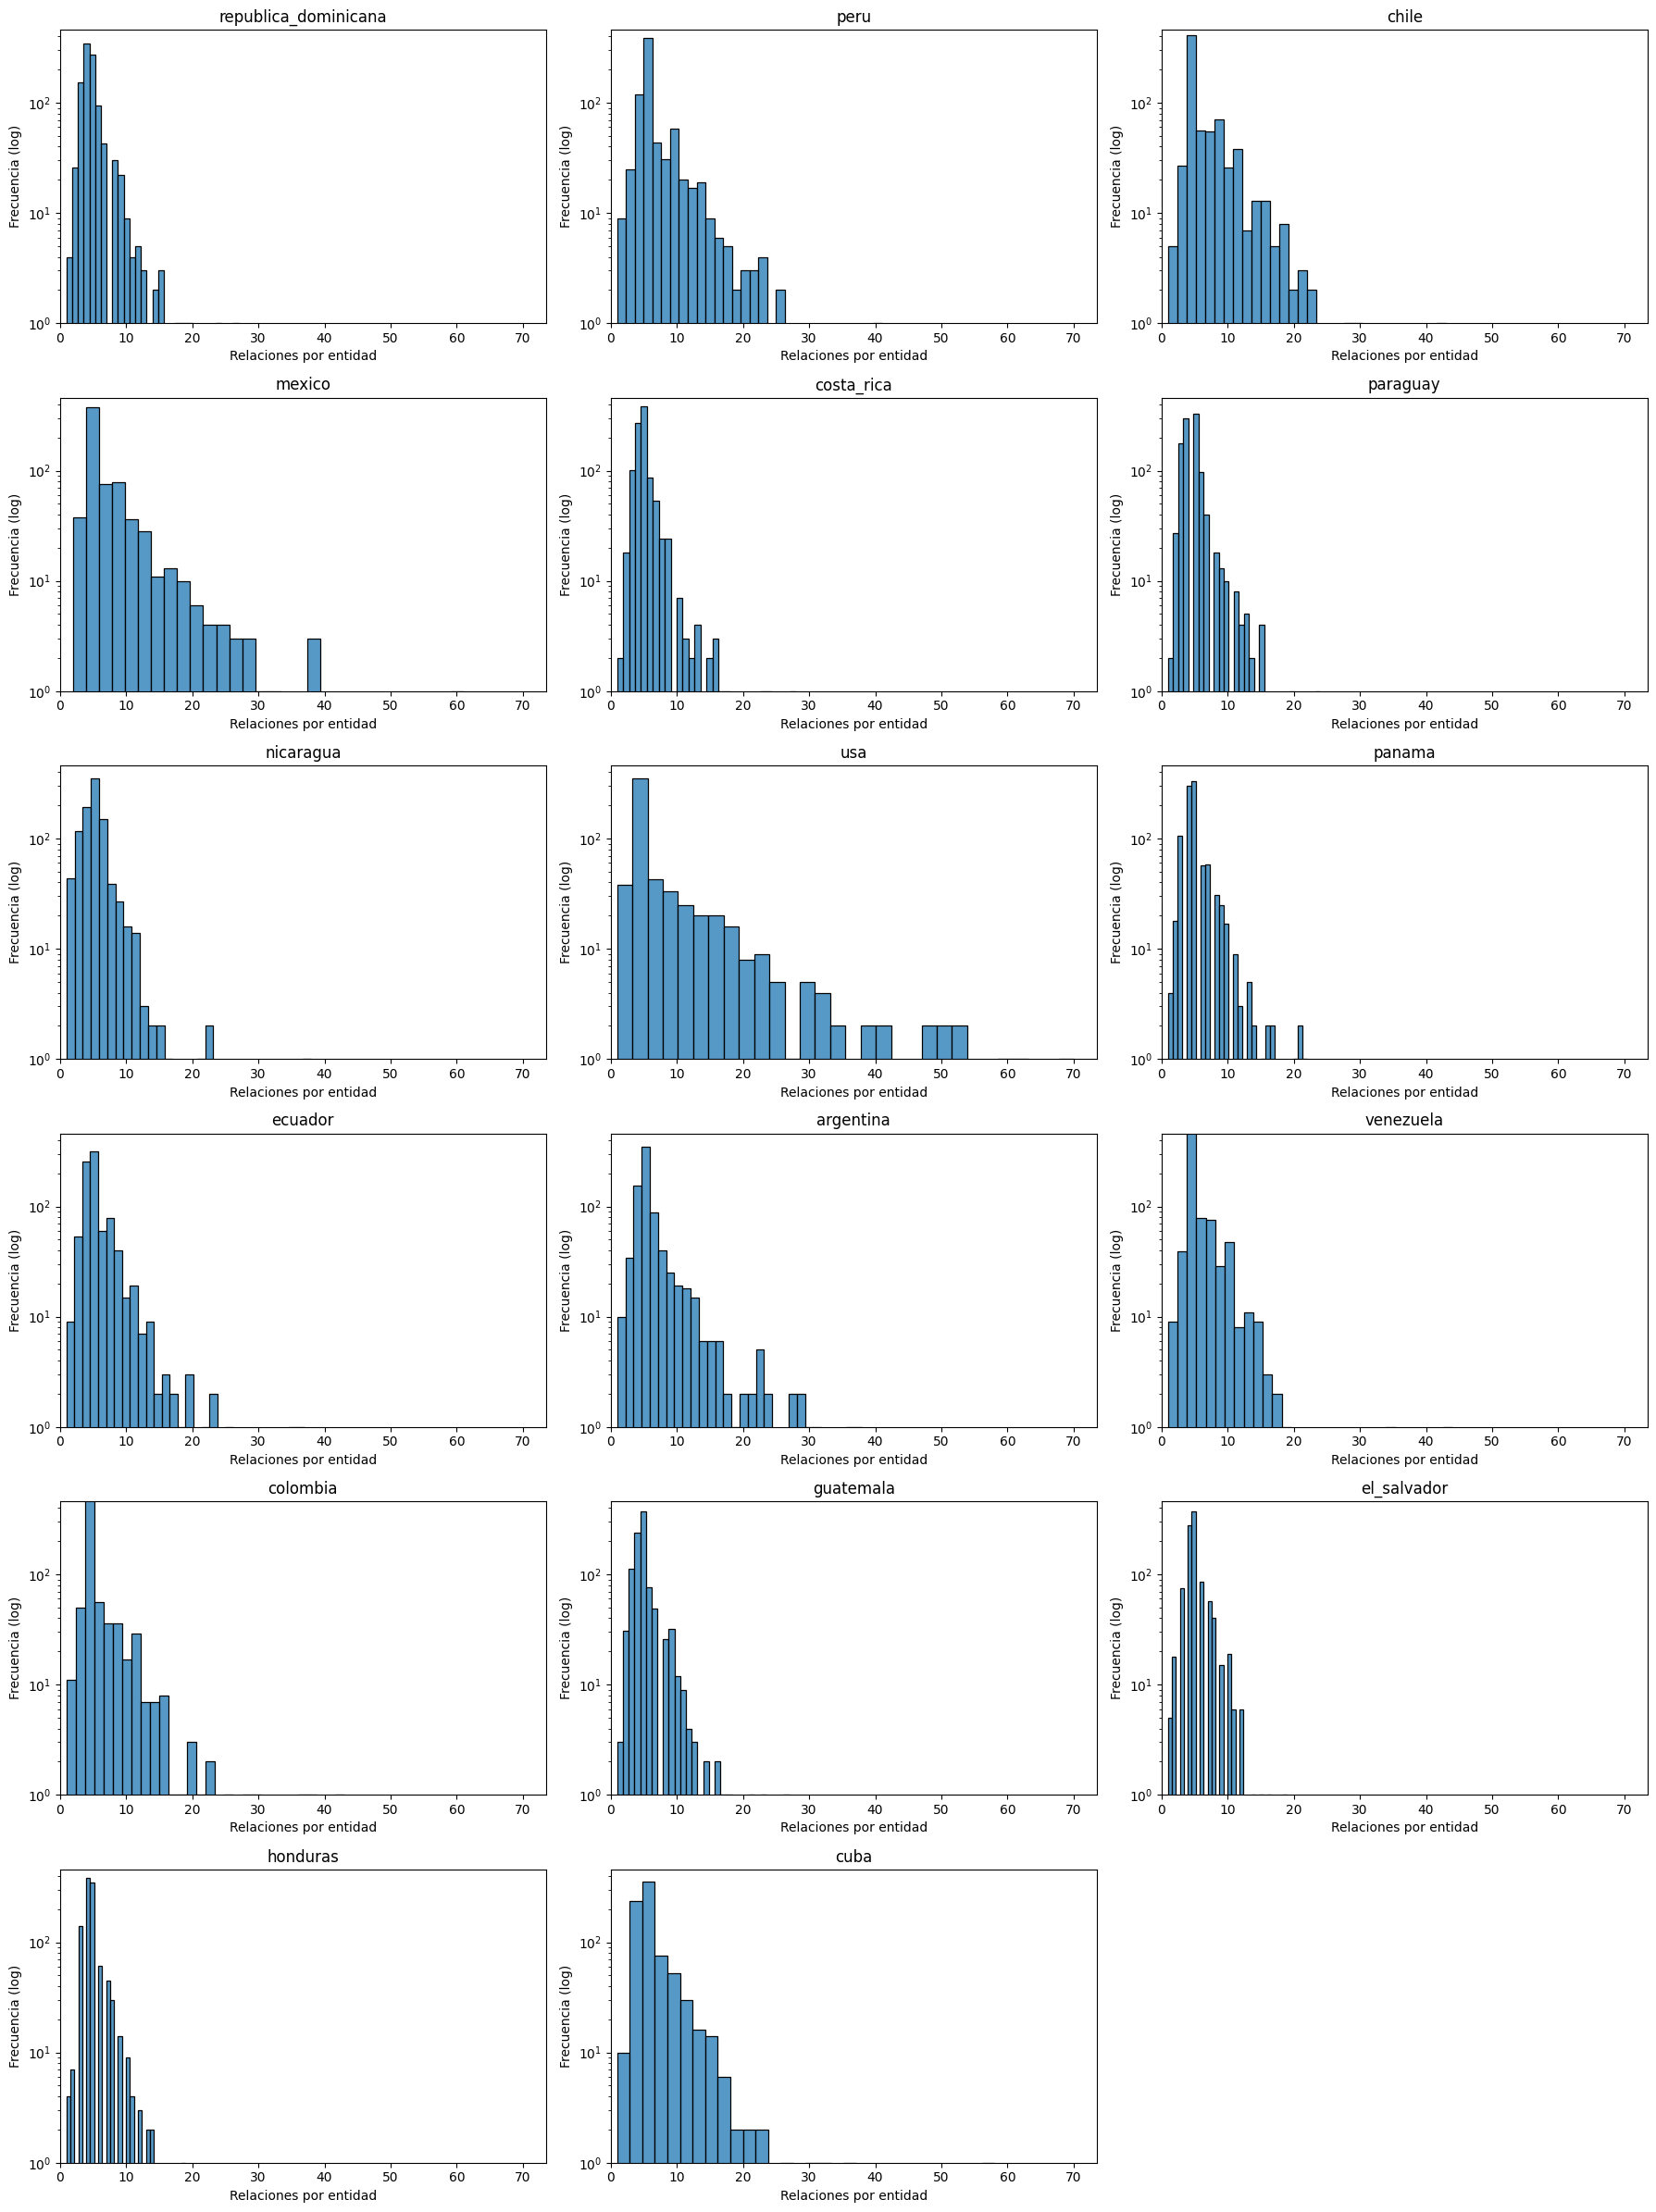

In [88]:
relations_per_entity_hist_all()

### 4) análisis de tipo de entidades

In [89]:
folder_entity_types = os.path.join(data_dir, "entity_types_clean")
files_entity_types = os.listdir(folder_entity_types)
roots_entitity_type = [folder_entity_types + "/" + file for file in files_entity_types if file_name.endswith('.csv')]
entity_types_dfs = {files_entity_types[i].split(".")[0]: pd.read_csv(roots_entitity_type[i]) for i in range(len(roots_entitity_type))}
big_entity_types_df = pd.concat(entity_types_dfs.values(), ignore_index=True)

In [102]:
filtered_entity_types_df = big_entity_types_df.loc[big_entity_types_df['tipo_entidad'].notnull()].copy()

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'municipio' if str(x).lower().startswith('municipio de') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'distrito' if str(x).lower().startswith('distrito de') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'estado' if str(x).lower().startswith('estado de') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'comunidad' if str(x).lower().startswith('comunidad de') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'provincia' if str(x).lower().startswith('provincia de') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'departamento' if str(x).lower().startswith('departamento de') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'cargo eclesiástico' if str(x).lower().startswith('obispo') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'comuna' if str(x).lower().startswith('comuna de') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'ser humano' if str(x).lower().startswith('página de desambiguación de nombres humanos') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'premio' if str(x).lower().startswith('premio literario') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'premio' if str(x).lower().startswith('premio literario') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'institución académica' if str(x).lower().startswith('academia') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'universidad' if str(x).lower().startswith('universidad') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'distinción' if str(x).lower().startswith('premio') else x
)

filtered_entity_types_df.loc[:, 'tipo_entidad'] = filtered_entity_types_df['tipo_entidad'].apply(
    lambda x: 'universidad' if str(x).lower().startswith('institución educativa universitaria') else x
)

filtered_entity_types_df.to_csv(os.path.join(data_dir,"entity_types_clean", "entity_types_cleaned.csv"), index=False)

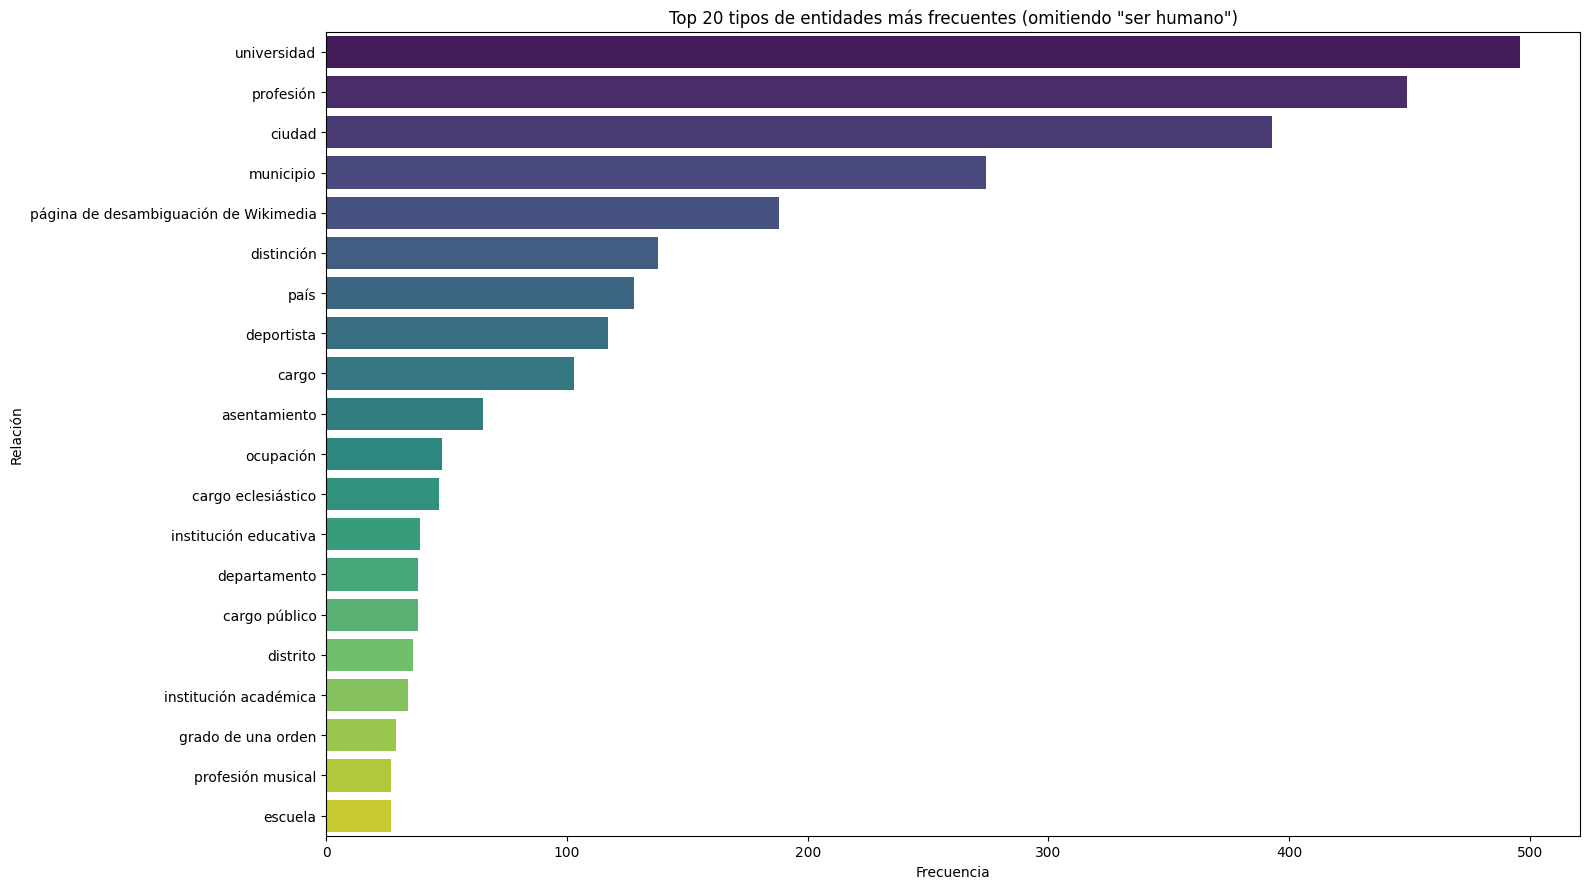

In [99]:
relation_counts = filtered_entity_types_df['tipo_entidad'].value_counts().reset_index()
relation_counts = relation_counts[relation_counts['tipo_entidad'] != "ser humano"]

top_n = 20
plt.figure(figsize=(16, 9))
sns.barplot(
    data=relation_counts.head(top_n),
    y='tipo_entidad',
    x='count',
    hue='tipo_entidad',
    palette='viridis',
    legend=False
)
plt.xlabel('Frecuencia')
plt.ylabel('Relación')
plt.title(f'Top {top_n} tipos de entidades más frecuentes (omitiendo "ser humano")')
plt.tight_layout()
plt.show()